# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Cornelius
- Email: sw.cornel@gmail.com
- Id Dicoding: cswynt

## Persiapan

### Menyiapkan library yang dibutuhkan

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import joblib

### Menyiapkan data yang akan digunakan

In [89]:
df = pd.read_csv('data.csv', sep=';')

df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')

df.rename(columns={'Status': 'Target'}, inplace=True)

df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

Dataset ini berisi informasi terkait mahasiswa dari berbagai program studi, termasuk faktor akademik, demografi, dan ekonomi.

Target dari dataset ini adalah memprediksi apakah mahasiswa akan:
- Dropout
- Enrolled
- Graduate

Fokus utama proyek ini adalah mengidentifikasi mahasiswa yang berpotensi dropout.

In [90]:
df.info()
df.describe()
df['Target'].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   int64  
 10 

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

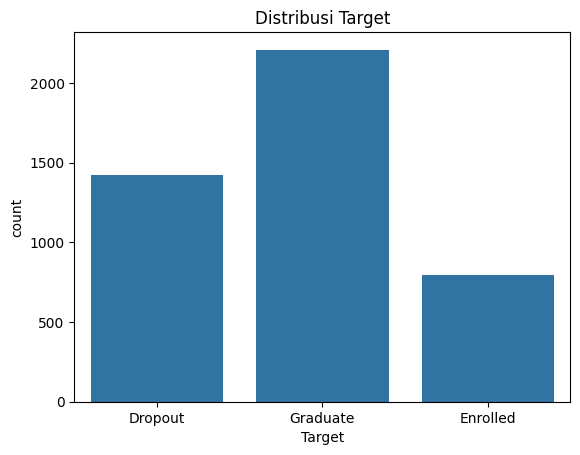

In [91]:
sns.countplot(x='Target', data=df)
plt.title("Distribusi Target")
plt.show()

## Exploratory Data Analysis (EDA)

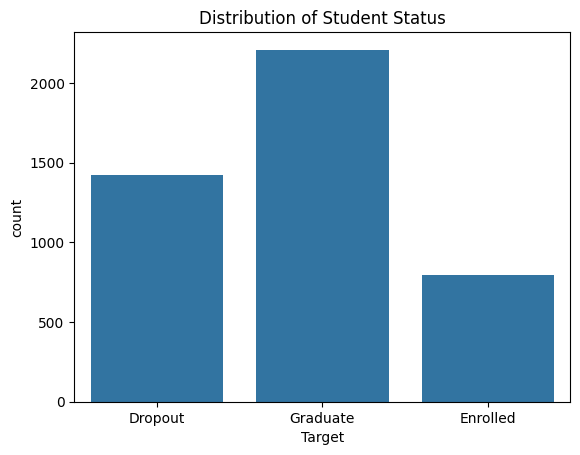

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Target', data=df)
plt.title("Distribution of Student Status")
plt.show()

Distribusi data menunjukkan perbandingan antara mahasiswa yang dropout dan graduate. 
Hal ini penting untuk memahami keseimbangan dataset sebelum modeling.

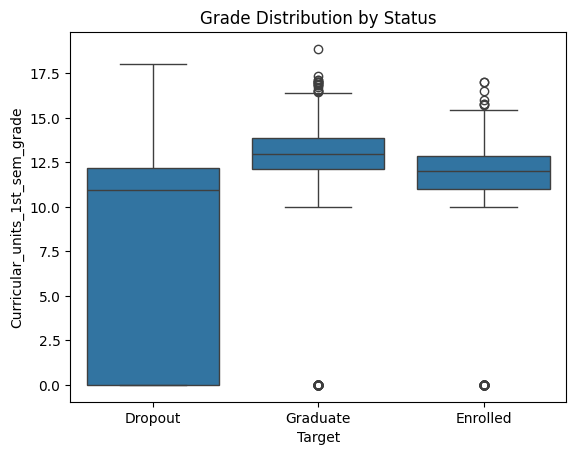

In [93]:
sns.boxplot(x='Target', y='Curricular_units_1st_sem_grade', data=df)
plt.title("Grade Distribution by Status")
plt.show()

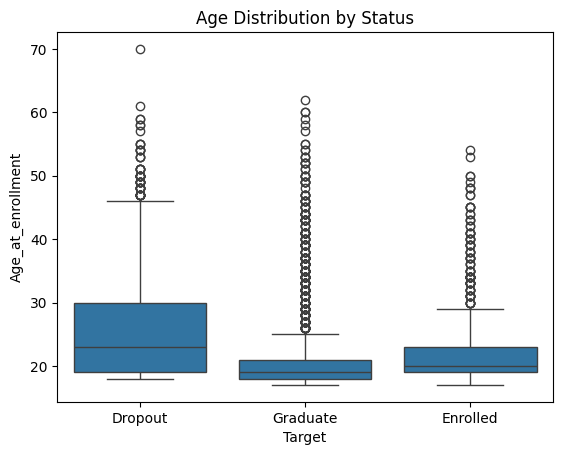

In [94]:
sns.boxplot(x='Target', y='Age_at_enrollment', data=df)
plt.title("Age Distribution by Status")
plt.show()

Mahasiswa dengan nilai akademik yang lebih rendah cenderung memiliki risiko dropout lebih tinggi.
Selain itu, terdapat variasi usia yang dapat mempengaruhi performa akademik.

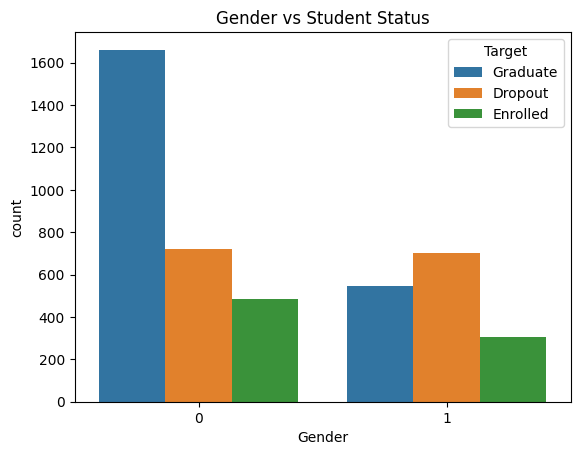

In [95]:
sns.countplot(x='Gender', hue='Target', data=df)
plt.title("Gender vs Student Status")
plt.show()

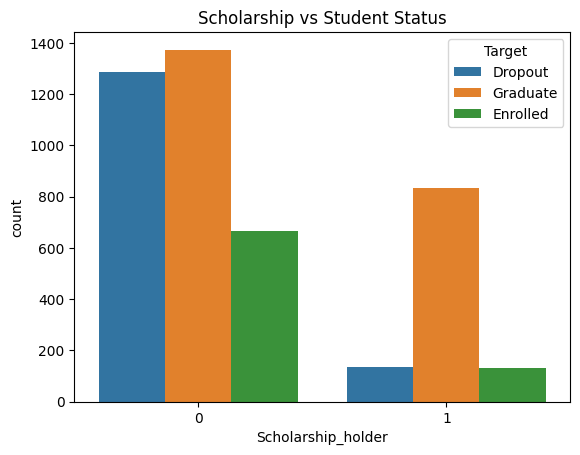

In [96]:
sns.countplot(x='Scholarship_holder', hue='Target', data=df)
plt.title("Scholarship vs Student Status")
plt.show()

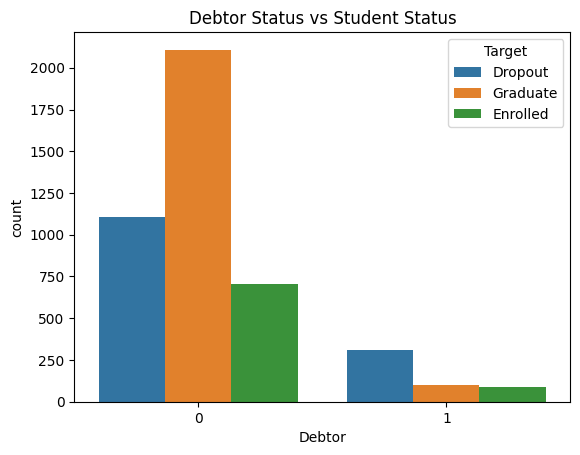

In [97]:
sns.countplot(x='Debtor', hue='Target', data=df)
plt.title("Debtor Status vs Student Status")
plt.show()

Mahasiswa dengan status debtor memiliki kecenderungan dropout lebih tinggi.
Selain itu, mahasiswa yang tidak menerima beasiswa cenderung memiliki risiko dropout lebih besar.

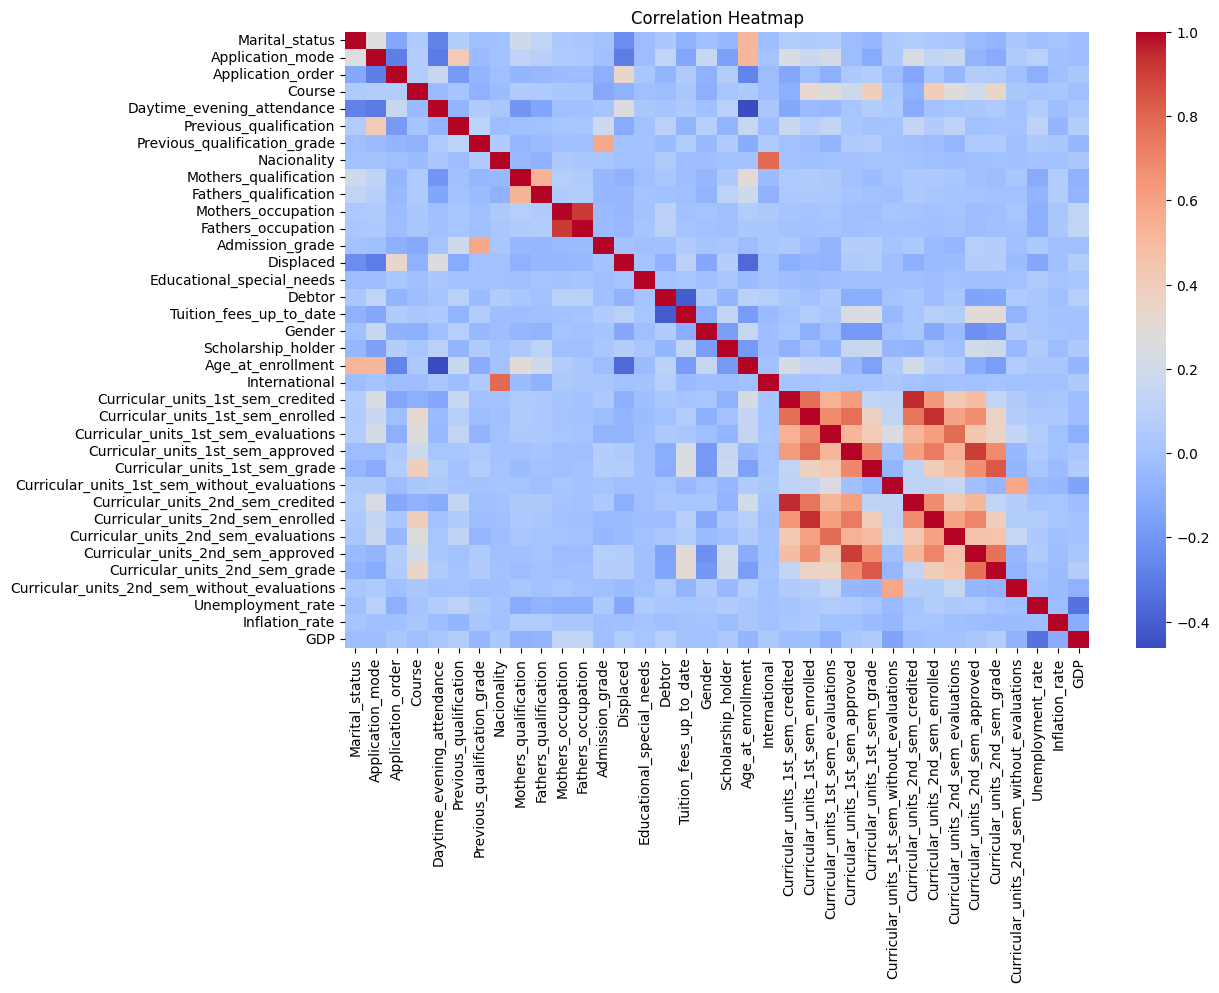

In [98]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Beberapa fitur seperti nilai semester dan jumlah mata kuliah yang disetujui menunjukkan korelasi kuat terhadap status mahasiswa.
Hal ini menunjukkan bahwa performa akademik merupakan faktor utama dalam menentukan kemungkinan dropout.

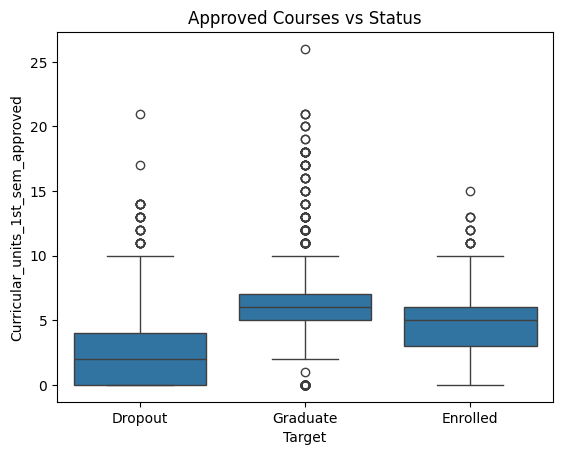

In [99]:
sns.boxplot(x='Target', y='Curricular_units_1st_sem_approved', data=df)
plt.title("Approved Courses vs Status")
plt.show()

Mahasiswa dengan jumlah mata kuliah yang disetujui lebih sedikit memiliki risiko dropout yang lebih tinggi.

## Data Preparation

Pada tahap ini dilakukan pembersihan dan pemilihan data yang relevan untuk proses modeling.

Data dengan status **Enrolled** tidak digunakan karena tidak merepresentasikan hasil akhir mahasiswa (belum dropout atau lulus).

Oleh karena itu, hanya data dengan status **Dropout** dan **Graduate** yang digunakan dalam proses modeling.

Pada tahap ini dilakukan:
- Feature engineering
- Konversi target menjadi binary (Dropout vs Non-Dropout)
- Pemisahan data training dan testing

In [100]:
# Filter hanya Dropout dan Graduate
df = df[df['Target'] != 'Enrolled']

# Encode target
df['Target_binary'] = df['Target'].apply(lambda x: 1 if x == 'Dropout' else 0)

df['Target'].value_counts()
df['Target_binary'].value_counts()

Target_binary
0    2209
1    1421
Name: count, dtype: int64

In [101]:
# Split fitur dan target
X = df.drop(['Target', 'Target_binary'], axis=1)
y = df['Target_binary']

In [102]:
df['total_approved'] = df['Curricular_units_1st_sem_approved'] + df['Curricular_units_2nd_sem_approved']

df['avg_grade'] = (
    df['Curricular_units_1st_sem_grade'] + 
    df['Curricular_units_2nd_sem_grade']
) / 2

In [103]:
df['Target_binary'] = df['Target'].apply(lambda x: 1 if x == 'Dropout' else 0)

In [104]:
X = df.drop(['Target', 'Target_binary'], axis=1)
y = df['Target_binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Modeling

In [105]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=2000)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

Feature scaling dilakukan khusus untuk Logistic Regression karena model ini sensitif terhadap perbedaan skala antar fitur. StandardScaler digunakan untuk menormalkan distribusi data sehingga model dapat melakukan konvergensi dengan lebih optimal.

In [106]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

## Evaluation

In [107]:
from sklearn.metrics import accuracy_score, classification_report

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression
Accuracy: 0.9118457300275482
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       449
           1       0.92      0.84      0.88       277

    accuracy                           0.91       726
   macro avg       0.91      0.90      0.91       726
weighted avg       0.91      0.91      0.91       726



In [108]:
print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest
Accuracy: 0.8966942148760331
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       449
           1       0.92      0.80      0.85       277

    accuracy                           0.90       726
   macro avg       0.90      0.88      0.89       726
weighted avg       0.90      0.90      0.90       726



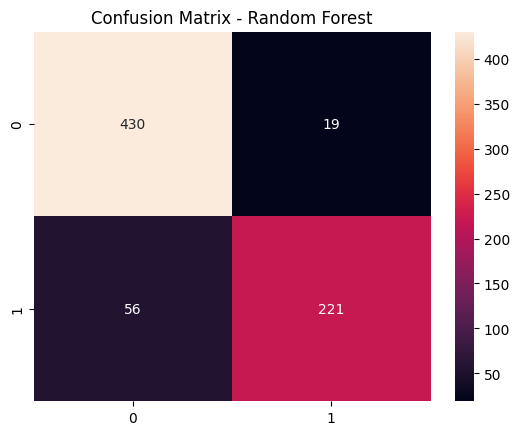

In [109]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.show()

## Evaluasi Model

Berdasarkan hasil evaluasi:

- Logistic Regression memberikan performa yang cukup baik sebagai baseline model
- Random Forest menunjukkan performa yang lebih tinggi, terutama dalam mendeteksi mahasiswa yang berpotensi dropout

Hal ini dikarenakan Random Forest mampu menangkap hubungan non-linear antar fitur, yang tidak dapat ditangkap dengan baik oleh Logistic Regression.

## Pemilihan Model

Model yang dipilih adalah **Random Forest**, karena memiliki performa terbaik dalam hal akurasi dan kemampuan klasifikasi.

## Feature Importance

Untuk memahami faktor utama yang memengaruhi kemungkinan dropout, dilakukan analisis feature importance menggunakan model Random Forest.

In [110]:
import pandas as pd

feature_importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

feature_importances.head(10)

,feature,importance
30,Curricular_units_2nd_sem_approved,0.202737
36,total_approved,0.165132
31,Curricular_units_2nd_sem_grade,0.087130
24,Curricular_units_1st_sem_approved,0.083619
37,avg_grade,0.065843
16,Tuition_fees_up_to_date,0.052019
25,Curricular_units_1st_sem_grade,0.047366
19,Age_at_enrollment,0.024230
22,Curricular_units_1st_sem_enrolled,0.021769
3,Course,0.021014


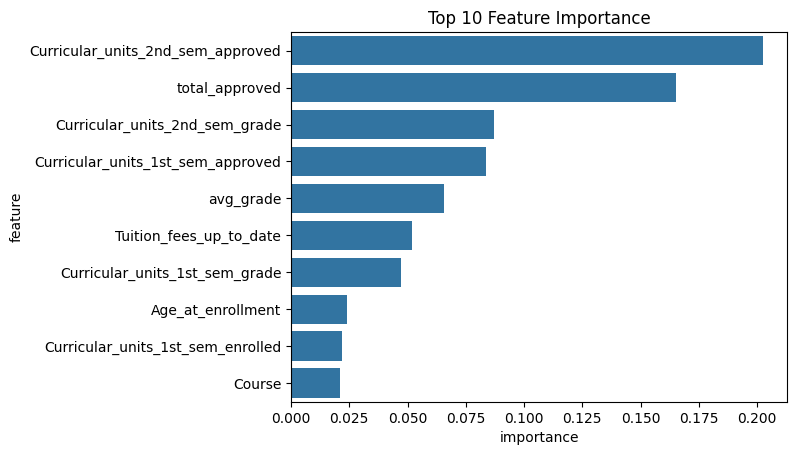

In [111]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    x='importance', 
    y='feature', 
    data=feature_importances.head(10)
)

plt.title("Top 10 Feature Importance")
plt.show()

## Insight Feature Importance

Fitur yang paling berpengaruh terhadap kemungkinan dropout antara lain:

- Nilai semester 1 dan 2
- Jumlah mata kuliah yang disetujui
- Status pembayaran tuition
- Admission grade

Hal ini menunjukkan bahwa performa akademik merupakan faktor utama dalam menentukan risiko dropout mahasiswa.

In [112]:
import os
import joblib

os.makedirs('model', exist_ok=True)

joblib.dump(X.columns.tolist(), 'model/features.pkl')

joblib.dump(rf, 'model/model.pkl')

['model/model.pkl']

## Conclusion

Berdasarkan hasil analisis dan pemodelan yang telah dilakukan, dapat disimpulkan bahwa:

1. Model machine learning mampu memprediksi kemungkinan mahasiswa dropout dengan performa yang cukup baik, dengan Logistic Regression sebagai model terbaik berdasarkan akurasi.

2. Faktor utama yang memengaruhi kemungkinan dropout adalah performa akademik mahasiswa, terutama nilai pada semester awal dan jumlah mata kuliah yang berhasil diselesaikan.

3. Faktor finansial seperti status pembayaran tuition juga memiliki pengaruh signifikan terhadap kemungkinan mahasiswa untuk dropout.

4. Data awal seperti admission grade dapat digunakan sebagai indikator awal untuk mengidentifikasi mahasiswa yang berisiko.

Dengan demikian, pendekatan berbasis data dapat membantu institusi dalam mengidentifikasi risiko dropout secara lebih dini.

## Action Items

Berdasarkan hasil analisis, berikut beberapa rekomendasi yang dapat diterapkan oleh Jaya Jaya Institut:

1. **Implementasi Early Warning System**  
   Menggunakan model machine learning untuk mendeteksi mahasiswa yang berpotensi dropout sejak awal semester.

2. **Monitoring Akademik Intensif**  
   Memberikan perhatian khusus kepada mahasiswa dengan nilai rendah atau jumlah mata kuliah yang tidak lulus tinggi.

3. **Dukungan Finansial**  
   Mengidentifikasi mahasiswa dengan masalah pembayaran tuition dan memberikan solusi seperti beasiswa atau skema cicilan.

4. **Program Mentoring dan Konseling**  
   Menyediakan pendampingan akademik dan psikologis untuk membantu mahasiswa yang mengalami kesulitan.

5. **Intervensi Berdasarkan Data Admission**  
   Mahasiswa dengan admission grade rendah dapat diberikan program persiapan tambahan sejak awal.

Implementasi langkah-langkah ini diharapkan dapat menurunkan angka dropout dan meningkatkan tingkat kelulusan mahasiswa.